# Интеллектуальный анализ данных – весна 2022

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [50]:
n_total=10
n_k1=8
n_k2=2
p_k1=n_k1/n_total
p_k2=n_k2/n_total

entropy=-(p_k1*np.log(p_k1)+p_k2*np.log(p_k2))
res=round(entropy,2)
print(res)

0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [51]:
n_total=10
n_k1=8
n_k2=2
p1_rm=n_k1/n_total
p2_rm=n_k2/n_total

H_Rm=p1_rm*(1-p1_rm)+p2_rm*(1-p2_rm)

n_left=8
p1_left=1.0
p2_left=0.0
H_Rl=p1_left*(1-p1_left)+p2_left*(1-p2_left)

n_right=2
p1_right=1.0
p2_right=0.0
H_Rr=p1_right*(1-p1_right)+p2_right*(1-p2_right)

Q=H_Rm-(n_left/n_total)*H_Rl-(n_right/n_total)*H_Rr


res=round(Q,2)
print(res)

0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [54]:
# Регрессия = в каждом листе одинаковое предсказание
val=np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47])
preds=np.mean(val)
print(preds)

40.6


## Часть 2: Решающие деревья (5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [ ]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы.

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

Разрешается делать цикл для перебора порогов, но возможна имплементация без него.

In [ ]:
# Первый вариант
# Векторизована для вещественных, а для категориальных нет
def find_best_split1(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————-

    # Преобразую в numpy массивы - так удобнее
    if isinstance(feature_vector, pd.DataFrame):
      feature_vector=feature_vector.values.flatten()
    if isinstance(target_vector, pd.Series):
      target_vector=target_vector.values

    n=len(feature_vector)

    # Проверочка на пустоту
    if n==0:
      return np.array([]), np.array([]), 0.0, 0.0

    # Функция для меры хаотичности
    def compute_chaos(values):
      if task == "classification":
        # Критерий Джинни для классификации
        classes, counts=np.unique(values,return_counts=True)
        probabilities=counts/len(values)
        return 1 - np.sum(probabilities**2)
      else:
        # Регрессия, диспресия для неё
        if len(values)==0:
          return 0
        return np.var(values)

    # Общая мера хаотичности
    H_R=compute_chaos(target_vector)

    if feature_type == "real":
      # Для вещественных признаков
      # Сортирую признаки и соотвествующие цели
      sorted_indexes=np.argsort(feature_vector)
      sorted_features=feature_vector[sorted_indexes]
      sorted_targets=target_vector[sorted_indexes]

      # Уникальные значения признака
      unique_features=np.unique(sorted_features)

      # Если все значения одинаковы (нет уникальных), то разбиение невозможно
      if len(unique_features)<=1:
        return np.array([]), np.array([]), 0.0, 0.0

      # Вычисляю пороги по инструкции - как среднее двух соседних (при сортировке) значений признака
      thresholds=(unique_features[:-1]+unique_features[1:])/2

      gains=[]
      valid_thresholds=[]

      for threshold in thresholds:
        # Разбиваю данные по фрешхолду
        left_mask=feature_vector<=threshold
        right_mask=feature_vector>threshold

        # Разбиения, где с одной стороны пусто, нас не интересуют
        if np.sum(left_mask)==0 or np.sum(right_mask)==0:
          continue

        left_targets=target_vector[left_mask]
        right_targets=target_vector[right_mask]

        # Хаотичность в получившихся левых и правых поддеревьях
        H_left=compute_chaos(left_targets)
        H_right=compute_chaos(right_targets)

        # Теперь gain получившийся
        n_left=len(left_targets)
        n_right=len(right_targets)
        # Информационный прирост - хаотичности до разбиения и взвешенной хаотичности после разбиения
        # Чем он больше, тем лучше! - сильнее контролируем и убираем неопределённость
        gain=H_R-(n_left/n)*H_left-(n_right/n)*H_right

        gains.append(gain)
        valid_thresholds.append(threshold)

      # Проверочка на пустоту
      if len(gains)==0:
        return np.array([]),np.array([]),0.0, 0.0

      gains=np.array(gains)
      valid_thresholds=np.array(valid_thresholds)

      # Лучший порожек по инструкции - минимальный сплит среди одинаковых критериев Джинни
      max_gain=np.max(gains)
      best_indexes=np.where(gains==max_gain)[0]
      # Тут он по индексу
      best_threshold=best_indexes[np.argmin(valid_thresholds[best_indexes])]

      # А тут уже нормальный реальный порожек
      threshold_best=valid_thresholds[best_threshold]
      gain_best=gains[best_threshold]

      return valid_thresholds, gains, threshold_best, gain_best

    else:
      # Теперь для категориальных признаков
      unique_values=np.unique(feature_vector)

      gains=[]
      valid_values=[]

      for value in unique_values:
        # Использую наивный алгоритм - с одним значением в одно поддерево, другие в другое
        left_mask=feature_vector==value
        right_mask=feature_vector!=value

        # Опять исключаем пустышек!
        if np.sum(left_mask)==0 or np.sum(right_mask)==0:
          continue

        left_targets=target_vector[left_mask]
        right_targets=target_vector[right_mask]

        # Опять считаем хаос в поддеревьях
        H_left=compute_chaos(left_targets)
        H_right=compute_chaos(right_targets)

        # Теперь gain
        n_left=len(left_targets)
        n_right=len(right_targets)
        gain=H_R-(n_left/n)*H_left-(n_right/n)*H_right

        gains.append(gain)
        valid_values.append(value)

      # Пустышки
      if len(gains)==0:
        return np.array([]), np.array([]), 0.0, 0.0

      gains=np.array(gains)
      valid_values=np.array(valid_values)

      # Лучший порожек по инструкции - минимальный сплит среди одинаковых приростов
      max_gain=np.max(gains)
      best_indexes=np.where(gains==max_gain)[0]
      # Тут он по индексу
      best_threshold=best_indexes[np.argmin(valid_values[best_indexes])]

      # А тут уже нормальный реальный порожек
      threshold_best=valid_values[best_threshold]
      gain_best=gains[best_threshold]

      return valid_values, gains, threshold_best, gain_best

    pass

In [ ]:
# Второй вариант
# Векторизована полностью, как и моя нервная система
def find_best_split2(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————-

    # Преобразую в numpy массивы - так удобнее
    if isinstance(feature_vector, pd.DataFrame):
      feature_vector=feature_vector.values.flatten()
    if isinstance(target_vector, pd.Series):
      target_vector=target_vector.values

    n=len(feature_vector)

    # Проверочка на пустоту
    if n==0:
      return np.array([]), np.array([]), 0.0, 0.0

    if feature_type=="real":
      # Для вещественных признаков
      # Сортируем признаки и тергеты для них
      sorted_indexes=np.argsort(feature_vector)
      sorted_features=feature_vector[sorted_indexes]
      sorted_targets=target_vector[sorted_indexes]

      # Уникальные значение признака
      # Есть отсортированный массив, теперь мы сравниваем каждый элемент с предыдущим
      # В начале True - первое уникально, а дальше сравниваем уникальность
      diff_mask=np.concatenate(([True],sorted_features[1:]!=sorted_features[:-1]))
      # Теперь находим индексы тру
      unique_indexes=np.where(diff_mask)[0]

      if len(unique_indexes)<=1:
        return np.array([]),np.array([]), 0.0, 0.0

      # Те же пороги
      thresholds=(sorted_features[unique_indexes[:-1]]+sorted_features[unique_indexes[1:]])/2

      # Теперь они разделены
      if task=="regression":
        # Полностью веторизованная версия для регрессии
        # Для эффективного вычисления использую кумулятивные суммы
        # Последовательное суммирование элементов массивы
        # Так как нужно вычислять статистики для разных частей, без них пришлось бы заново считать

        # Общая дисперсия
        # ddof - Delta Degrees of Freedom - степени свободы - нам нужно 0 - MSE
        total_var=np.var(target_vector, ddof=0)
        # Как раз суммы для быстрого вычисления статистик
        # Одна просто объектов, другая квадратов
        cumsum=np.cumsum(sorted_targets)
        cumsum2=np.cumsum(sorted_targets**2)

        # Для каждого возможного разбиения, которое раположено после уникального значения
        split_indexes=unique_indexes[:-1]

        # Количество элементов для разбиений
        left_counts=split_indexes+1
        right_counts=n-left_counts

        # Теперь суммы для каждых
        left_sums=cumsum[split_indexes]
        left_sums2=cumsum2[split_indexes]

        right_sums=cumsum[-1]-left_sums
        right_sums2=cumsum2[-1]-left_sums2

        # Дисперсии для регрессии
        left_vars=left_sums2/left_counts-(left_sums/left_counts)**2
        right_vars=right_sums2/right_counts-(right_sums/right_counts)**2

        # Информационный прирост
        gains=total_var-(left_counts/n)*left_vars-(right_counts/n)*right_vars

      else:
        # то есть таск classification
        # Векторизованная для классификации
        # Ищем уникальные классы
        # Unique Classes - отсортированный массив уникальных значений классов
        # Class Indexes - массив индексов, который показывает, к какому уникальному классу относится каждый элемент
        unique_classes, class_indexes=np.unique(target_vector,return_inverse=True)
        n_classes=len(unique_classes)

        # One-hot кодирование этих классов
        one_hot=np.zeros((n,n_classes))
        one_hot[np.arange(n), class_indexes[sorted_indexes]]=1

        # Общий критерий Джинни
        class_counts=np.sum(one_hot,axis=0)
        class_probs=class_counts/n
        total_gini=1-np.sum(class_probs**2)

        # Аналогичные кумулятивные суммы
        cum_counts=np.cumsum(one_hot, axis=0)

        split_indexes=unique_indexes[:-1]

        left_counts=split_indexes+1
        right_counts=n-left_counts

        # Количество объектов каждого класса в разных частях
        left_class_counts=cum_counts[split_indexes, :]
        right_class_counts=class_counts-left_class_counts

        # Доли классов в каждой части
        left_probs=left_class_counts/left_counts[:,np.newaxis]
        right_probs=right_class_counts/right_counts[:,np.newaxis]

        # Критерий Джинни для левых и правых частей
        left_ginis=1-np.sum(left_probs**2,axis=1)
        right_ginis=1-np.sum(right_probs**2,axis=1)

        # Инормационный прирост
        gains=total_gini-(left_counts/n)*left_ginis-(right_counts/n)*right_ginis

      # Удаляем пустышек
      empty_mask=(left_counts>0)&(right_counts>0)

      if not np.any(empty_mask):
        return np.array([]), np.array([]), 0.0, 0.0

      thresholds=thresholds[empty_mask]
      gains=gains[empty_mask]

      if len(gains)==0:
        return np.array([]), np.array([]), 0.0, 0.0

    else:
      # Теперь для категориальных
      unique_values=np.unique(feature_vector)
      n_unique=len(unique_values)

      if n_unique<=1:
        return np.array([]), np.array([]), 0.0, 0.0

      # Всё будем делать через матричные операции - вычисляем сразу для всех статистики
      # Создаю матрицу сравнений для векторизации
      # Она размером (n,n_unique) - каждый столбец маска для одного значение
      val_masks=(feature_vector[:,np.newaxis]==unique_values)

      if task=="regression":
        # Общая дисперсия
        total_var=np.var(target_vector,ddof=0)

        left_counts=np.sum(val_masks,axis=0)

        ok_mask=(left_counts>0)&(left_counts<n)

        if not np.any(ok_mask):
          return np.array([]), np.array([]), 0.0, 0.0

        unique_values=unique_values[ok_mask]
        val_masks=val_masks[:,ok_mask]
        left_counts=left_counts[ok_mask]
        n_unique=len(unique_values)

        right_counts=n-left_counts

        # Суммы целевых переменных
        left_sums=val_masks.T@target_vector
        # Суммы квадратов целевых переменных
        left_sums2=val_masks.T@(target_vector**2)

        total_sum=np.sum(target_vector)
        total_sum2=np.sum(target_vector**2)

        right_sums=total_sum-left_sums
        right_sums2=total_sum2-left_sums2

        # Дисперсии
        left_vars=left_sums2/left_counts-(left_sums/left_counts)**2
        right_vars=right_sums2/right_counts-(right_sums/right_counts)**2

        gains=total_var-(left_counts/n)*left_vars-(right_counts/n)*right_vars

      else:
        # то есть classification
        # Уникальные классы
        unique_classes, class_indexes=np.unique(target_vector,return_inverse=True)
        n_classes=len(unique_classes)

        # One-hot кодирование
        target_one_hot=np.zeros((n,n_classes))
        target_one_hot[np.arange(n),class_indexes]=1

        # Критерий Джини
        class_counts=np.sum(target_one_hot,axis=0)
        class_probs=class_counts/n
        total_gini=1-np.sum(class_probs**2)

        # Аналогично подсчитываем количество элементов и убираем пустышек и переборов
        left_counts=np.sum(val_masks,axis=0)

        ok_mask=(left_counts>0)&(left_counts<n)

        if not np.any(ok_mask):
          return np.array([]), np.array([]), 0.0, 0.0

        unique_values=unique_values[ok_mask]
        val_masks=val_masks[:,ok_mask]
        left_counts=left_counts[ok_mask]
        n_unique=len(unique_values)

        right_counts=n-left_counts
        left_class_counts=val_masks.T.astype(float)@target_one_hot
        right_class_counts=class_counts-left_class_counts

        # Теперь доли
        left_probs=left_class_counts/left_counts[:,np.newaxis]
        right_probs=right_class_counts/right_counts[:,np.newaxis]

        # Критерий Джинни
        left_ginis=1-np.sum(left_probs**2,axis=1)
        right_ginis=1-np.sum(right_probs**2,axis=1)

        # Информационный прирост
        gains=total_gini-(left_counts/n)*left_ginis-(right_counts/n)*right_ginis

      thresholds=unique_values

    # Теперь лучший порожек по инструкции
    if len(gains)==0:
      return np.array([]), np.array([]), 0.0, 0.0

    max_gain=np.max(gains)
    best_indexes=np.where(gains==max_gain)[0]

    best_subindex=np.argmin(thresholds[best_indexes])
    best_threshold=best_indexes[best_subindex]

    threshold_best=thresholds[best_threshold]
    gain_best=gains[best_threshold]

    return thresholds, gains, threshold_best, gain_best

    pass

Эту функцию можно протестировать на датасете `California`.

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def plot_gain_threshold1(feature_vector, target_vector, feature_name="Признак"):
  """
  График зависимости значения критерия ошиьки от порогового значения
  Для вещественного в регрессии
  """
  # Тут я игралась с двумя разными функциями, чтобы понять, насколько всё норм
  thresholds, gains, best_threshold, best_gain=find_best_split1(feature_vector, target_vector, task="regression",feature_type="real")

  # Проверка пустышки
  if len(thresholds)==0:
    print(f"Для нашего признака {feature_name} нет разбиений :(")
    return

  # Строим график, если всё ок
  plt.figure(figsize=(12, 6))

  # Кривая значения критерия ощибки
  plt.plot(thresholds, gains, "b-",linewidth=2,label=f"Информационный прирост (gain)")

  # Лучший порог
  plt.axvline(x=best_threshold, color="r",linestyle="--",linewidth=2, label=f"Лучший порожек: {best_threshold:.3f}")

  # Лучший Информационный прирост
  plt.axhline(y=best_gain, color="g",linestyle=":",linewidth=2,label=f"Лучший Информационный прирост:{best_gain:.4f}")

  # И график делаем красивым
  plt.xlabel(f"Пороговое значение признака {feature_name}",fontsize=12)
  plt.ylabel(f"Значение критерия ошибки (gain)",fontsize=12)
  plt.title(f"Зависимость значения критерия ошибки от порогового значения\nПо признаку: {feature_name}",fontsize=12)

  plt.legend(loc="best", fontsize=10)
  plt.grid(True, alpha=0.3)
  plt.tight_layout()

  # И чуть-чуть информации
  print(f"Статистика для {feature_name}")
  print(f"Количество порогов: {len(thresholds)}")
  print(f"Диапазон порогов: [{thresholds.min():.3f},{thresholds.max():.3f}]")
  print(f"Лучший порожек: {best_threshold:.3f}")
  print(f"Лучшее значение ошибки: {best_gain:.4f}")
  print(f"Дисперсия до разбиения: {np.var(target_vector):.4f}")

  plt.show()
  return thresholds, gains, best_threshold, best_gain



Статистика для MedInc
Количество порогов: 12927
Диапазон порогов: [0.518,15.000]
Лучший порожек: 5.035
Лучшее значение ошибки: 0.4128
Дисперсия до разбиения: 1.3316


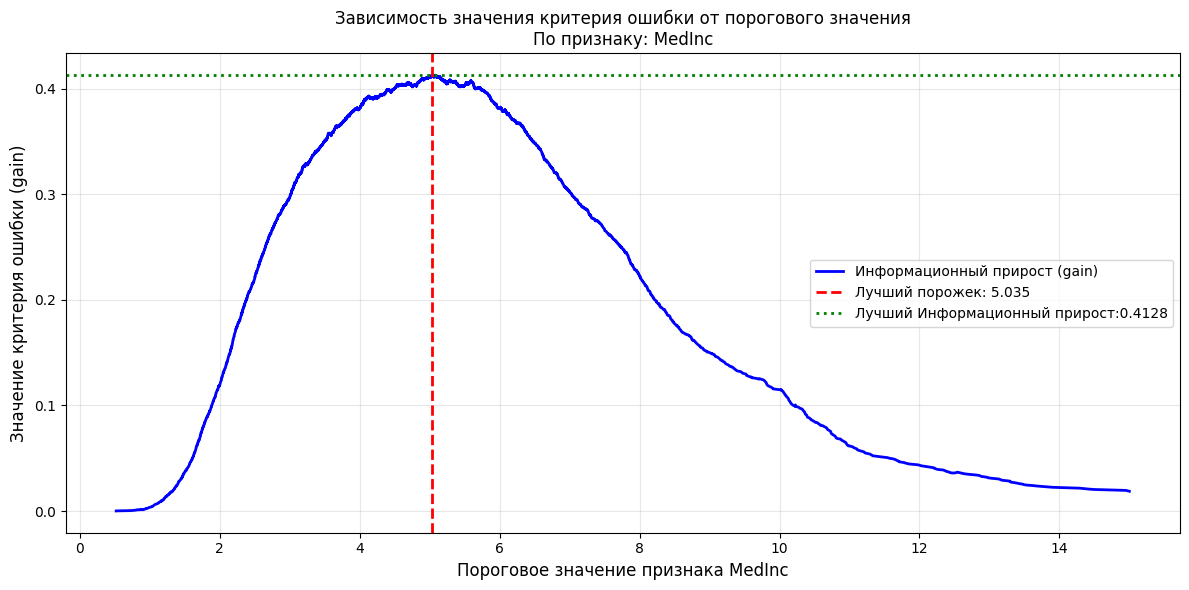

In [ ]:
# Проверяем по признаку
feature_name="MedInc"
feature_vector=X[feature_name].values
target_vector=y

thresholds,gains,best_thresholds,best_gain=plot_gain_threshold1(feature_vector,target_vector,feature_name)

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
# 2 векториозованнный вариант работает гораздо быстрее
def plot_gain_threshold2(feature_vector, target_vector, feature_name="Признак"):
  """
  График зависимости значения критерия ошиьки от порогового значения
  Для вещественного в регрессии
  """
  # Тут я игралась с двумя разными функциями, чтобы понять, насколько всё норм
  thresholds, gains, best_threshold, best_gain=find_best_split2(feature_vector, target_vector, task="regression",feature_type="real")

  # Проверка пустышки
  if len(thresholds)==0:
    print(f"Для нашего признака {feature_name} нет разбиений :(")
    return

  # Строим график, если всё ок
  plt.figure(figsize=(12, 6))

  # Кривая значения критерия ощибки
  plt.plot(thresholds, gains, "b-",linewidth=2,label=f"Информационный прирост (gain)")

  # Лучший порог
  plt.axvline(x=best_threshold, color="r",linestyle="--",linewidth=2, label=f"Лучший порожек: {best_threshold:.3f}")

  # Лучший Информационный прирост
  plt.axhline(y=best_gain, color="g",linestyle=":",linewidth=2,label=f"Лучший Информационный прирост:{best_gain:.4f}")

  # И график делаем красивым
  plt.xlabel(f"Пороговое значение признака {feature_name}",fontsize=12)
  plt.ylabel(f"Значение критерия ошибки (gain)",fontsize=12)
  plt.title(f"Зависимость значения критерия ошибки от порогового значения\nПо признаку: {feature_name}",fontsize=12)

  plt.legend(loc="best", fontsize=10)
  plt.grid(True, alpha=0.3)
  plt.tight_layout()

  # И чуть-чуть информации
  print(f"Статистика для {feature_name}")
  print(f"Количество порогов: {len(thresholds)}")
  print(f"Диапазон порогов: [{thresholds.min():.3f},{thresholds.max():.3f}]")
  print(f"Лучший порожек: {best_threshold:.3f}")
  print(f"Лучшее значение ошибки: {best_gain:.4f}")
  print(f"Дисперсия до разбиения: {np.var(target_vector):.4f}")

  plt.show()
  return thresholds, gains, best_threshold, best_gain

Статистика для MedInc
Количество порогов: 12927
Диапазон порогов: [0.518,15.000]
Лучший порожек: 5.035
Лучшее значение ошибки: 0.4128
Дисперсия до разбиения: 1.3316


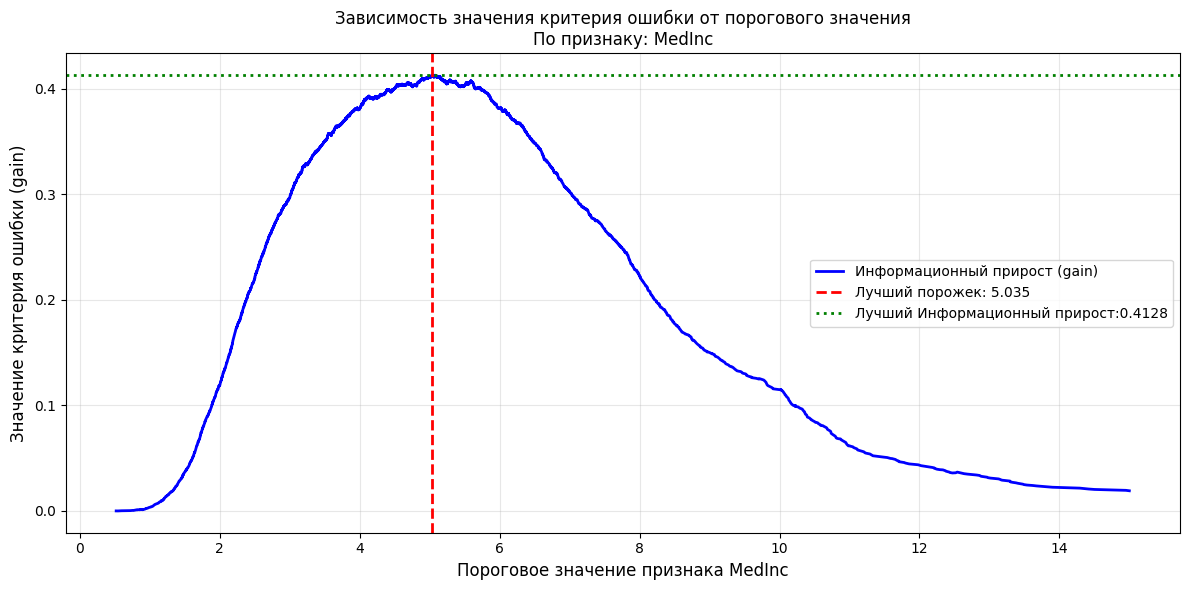

In [ ]:
# Проверяем по признаку
feature_name="MedInc"
feature_vector=X[feature_name].values
target_vector=y

thresholds,gains,best_thresholds,best_gain=plot_gain_threshold2(feature_vector,target_vector,feature_name)

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [31]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def find_best_root_split(X,y,task="regression"):
  """
  Находим лучший предикат для первой вершины решающего дерева

    X - матрица признаков
    y - вектор целевой переменной
    task - регрессия или классификация

    Возвращать буду информацию об этои лучшем разбиении

  """

  best_split_info={
      "feature_name": None,
      "threshold": None,
      "gain": -np.inf,
      "feature_index": None,
      "feature_type": None,
      "thresholds": None,
      "gains": None
  }

  # Пройду по всем признакам
  for i, feature_name in enumerate(X.columns):
    feature_vector=X[feature_name].values

    # Тип признака, str - категориальный, но в нашем датасете все вщественные
    if feature_vector.dtype==object or isinstance(feature_vector[0],str):
      feature_type="categorical"
    else:
      feature_type="real"

    # Пробуем
    try:
      thresholds, gains, best_threshold, best_gain=find_best_split2(feature_vector,y,task=task,feature_type=feature_type)

      if len(thresholds>0) and best_gain>best_split_info["gain"]:
        best_split_info.update({
          "feature_name": feature_name,
          "threshold": best_threshold,
          "gain": best_gain,
          "feature_index": i,
          "feature_type": feature_type,
          "thresholds": thresholds,
          "gains": gains
        })

    except Exception as e:
            print(f"Ошибка при обработке признака {feature_name}: {e}")
            continue

  return best_split_info

best_split=find_best_root_split(X, y, task="regression")

print("=" * 51)
print("ЛУЧШИЙ ПРЕДИКАТ ДЛЯ ПЕРВОЙ ВЕРШИНЫ РЕШАЮЩЕГО ДЕРЕВА")
print("=" * 51)
print(f"Признак: {best_split["feature_name"]}")
print(f"Тип признака: {best_split["feature_type"]}")
print(f"Оптимальный порог: {best_split["threshold"]:.4f}")
print(f"Максимальный прирост: {best_split["gain"]:.4f}")
print(f"Индекс признака: {best_split["feature_index"]}")



ЛУЧШИЙ ПРЕДИКАТ ДЛЯ ПЕРВОЙ ВЕРШИНЫ РЕШАЮЩЕГО ДЕРЕВА
Признак: STG
Тип признака: real
Оптимальный порог: 0.4050
Максимальный прирост: 0.0167
Индекс признака: 1


**Задание 2.2 (1.5 балла)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму:
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

Также:
- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [48]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification",
        missing_value_strategy: str = "most_frequent" # "most_frequent", "mean"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        self.missing_value_strategy = missing_value_strategy
        self._feature_importances = {}
        self._fitted = False
        self._unique_classes = None

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}

    def _manage_missing_values(self, X: np.ndarray)->np.ndarray:
      """
      Обрабатываем пропущенные значние в данных
      Три разных способа:
          "most_frequent" - самое частое - для категориальных буквально, для вещественных медиану берём
          "mean" - для категориальных мода, для вещественных среднее
      # """
      X_processed=X.copy()

      for i in range(X.shape[1]):
        # Вещественные
        if self._feature_types[i]=="real":
          mask=np.isnan(X[:,i])
          if np.any(mask):
            if self.missing_value_strategy=="mean":
              fill_value=np.nanmean(X[:,i])
            else:
              fill_value=np.nanmedian(X[:,i])
            X_processed[mask,i]=fill_value
        # Категориальные
        else:
          # pd.isna - pandas для пропусков для строковых значениях и None
          # Если же pandas не получится, тогда numpy для чисел
          mask=pd.isna(X[:,i]) if hasattr(pd, "isna") else np.isnan(X[:,i])
          if np.any(mask):
            # Самое частое
            not_missing=X[~mask,i]
            if len(not_missing)>0:
              counter=Counter(not_missing)
              fill_value=counter.most_common(1)[0][0]
            else:
              fill_value="???"
            X_processed[mask,i]=fill_value

      return X_processed

    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict,
        depth: int=0
    ) -> None:

        # Реализация чуть другая под мои функции
        # Критерии останова - три штуки получилось
        stop_conditions=[]

        # 1
        # Все объекты одного класса(для классификации), минимальная дисперсия(для регрессии)
        if self.task=="classification":
          if np.all(sub_y==sub_y[0])or len(np.unique(sub_y))==1:
            stop_conditions.append(("all_the_same_class",True))
        else:
          # regression
          # Берём констансту и меньше её
          if np.var(sub_y)<1e-10:
            stop_conditions.append(("low_variance",True))

        # 2
        # Достигнута максимальная глубина
        if self._max_depth is not None and depth>=self._max_depth:
          stop_conditions.append(("max_depth",True))

        # 3
        # Объектов для разбиения слишком мало
        if self._min_samples_split is not None and len(sub_y)<self._min_samples_split:
          stop_conditions.append(("min_samples_split",True))

        # Заканчиваем всё, если что-то выполнилось - терминальный узел
        if stop_conditions:
          node["type"]="terminal"
          if self.task=="classification":
            # Считаем частоту каждого класса и выбираем самый частый и получает его [0][0]
            node["class"]=Counter(sub_y).most_common(1)[0][0]
          else:
            # опять регресссия эта - тут среднее значение целевой переменной
            node["value"]=np.mean(sub_y)
          node["n_samples"]=len(sub_y)
          return

        # Теперь ищем лучшее разбиение
        feature_best,threshold_best,gini_best,split=None,None,-np.inf,None

        for feature in range(sub_X.shape[1]):

          feature_type=self._feature_types[feature]

          # Подготавливаем признак для поиска оптимального порога
          if feature_type == "real":
            feature_vector = sub_X[:, feature]
          elif feature_type == "categorical":
            # здесь не будет более сложного подхода
            feature_vector = sub_X[:, feature]

          # ищем оптимальный порог
          _, _, threshold, gini = find_best_split2(feature_vector, sub_y, self.task, feature_type)

          if gini is not None and (gini_best is None or gini > gini_best):
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector<=threshold_best
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = feature_vector==threshold_best
                else:
                    raise ValueError


        # записываем полученные сплиты в атрибуты класса
        if feature_best is None or gini_best<=0:
            node["type"] = "terminal"
            if self.task=="classification":
              node["class"] = Counter(sub_y).most_common(1)[0][0]
            else:
              node["value"]=np.mean(sub_y)
            node["n_samples"]=len(sub_y)
            return

        # Проверка на минимальное количество объектов в листьях
        left_samples=np.sum(split)
        right_samples=len(sub_y)-left_samples

        if self._min_samples_leaf is not None:
          if left_samples<self._min_samples_leaf or right_samples<self._min_samples_leaf:
            node["type"]="terminal"
            if self.task=="classification":
              node["class"] = Counter(sub_y).most_common(1)[0][0]
            else:
              node["value"]=np.mean(sub_y)
            node["n_samples"]=len(sub_y)
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        node["gini_gain"]=gini_best
        node["n_samples"]=len(sub_y)

        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        # Обновляю важность признаков
        if feature_best not in self._feature_importances:
          self._feature_importances[feature_best]=0
        self._feature_importances[feature_best]+=gini_best*len(sub_y)

        # Рекурсивно строим деревья
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"], depth+1)
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"], depth+1)

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание. Для нелистовых узлов проверяем условие разбиения и выбираем поддерево
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
        if node["type"]=="terminal":
          return node["class"] if self.task=="classification" else node["value"]

        feature_index=node["feature_split"]
        feature_value=x[feature_index]


        # Основная логика
        if self._feature_types[feature_index]=="real":
            if feature_value<=node["threshold"]:
                return self._predict_node(x,node["left_child"])
            return self._predict_node(x,node["right_child"])
        else:
            # Категориальный признак
            if feature_value==node["category_split"]:
                return self._predict_node(x,node["left_child"])
            return self._predict_node(x,node["right_child"])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Обучение дерева
        """
        # Обрабатываем пустышек-пропускашек
        X_processed=self._manage_missing_values(X)

        # Сохраняю инфу о классах для классификации
        if self.task=="classification":
          self._unique_classes=np.unique(y)

        # Рассчитываем важность признаков
        self._feature_importances={i: 0.0 for i in range(X.shape[1])}

        # Строим дерево
        self._fit_node(X_processed, y, self._tree)
        self._fitted=True

        # Вот тут рассчитываем и нормируем, чтобы сумма была 1
        total_importance=sum(self._feature_importances.values())
        if total_importance>0:
          self._feature_importances={
              k: v/total_importance for k, v in self._feature_importances.items()
          }


    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Теперь предсказание не для одного, а для нескольких
        """
        if not self._fitted:
          raise ValueError("Дерево не обучено - сначала fit!")

        X_processed=self._manage_missing_values(X)
        predicted = []

        for x in X_processed:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

    def get_feature_importances(self, feature_names: List[str]=None) -> Dict:
        """
        Возвращаем важность признаков - при каждом разбиении она gini_gain*n_samples
        feature_names - список имён признаков(или индексы, если нет имён)

        Dict - словарь с важностью признаков
        """
        if not self._fitted:
          raise ValueError("Дерево не обучено - сначала fit!")

        if feature_names is not None:
          if len(feature_names)!=len(self._feature_importances):
            raise ValueError("Количество имён не совпадает с количеством признаков!")
          return {feature_names[i]:importance for i, importance in self._feature_importances.items()}
        else:
          return self._feature_importances.copy()

    def get_depth(self, node: dict =None)->int:
          """
          Глубина дерева
          """
          if node is None:
            node=self._tree
          if node["type"]=="terminal":
            return 1

          left_depth=self.get_depth(node["left_child"])
          right_depth=self.get_depth(node["right_child"])

          return max(left_depth, right_depth)+1

    def get_n_leaves(self, node: dict = None)->int:
      """
      Для количества листьев в дереве
      """
      if node is None:
        node=self._tree
      if node["type"]=="terminal":
        return 1

      return (self.get_n_leaves(node["left_child"]))+(self.get_n_leaves(node["right_child"]))

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков. Прокомментируйте получившиеся графики.

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

students_df=pd.read_csv("students.csv")
print(students_df.head())
print(students_df.info())
print(students_df.describe())

   Unnamed: 0   STG   SCG   STR   LPR   PEG  UNS
0           0  0.00  0.00  0.00  0.00  0.00    0
1           1  0.08  0.08  0.10  0.24  0.90    1
2           2  0.06  0.06  0.05  0.25  0.33    0
3           3  0.10  0.10  0.15  0.65  0.30    1
4           4  0.08  0.08  0.08  0.98  0.24    0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  258 non-null    int64  
 1   STG         258 non-null    float64
 2   SCG         258 non-null    float64
 3   STR         258 non-null    float64
 4   LPR         258 non-null    float64
 5   PEG         258 non-null    float64
 6   UNS         258 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 14.2 KB
None
       Unnamed: 0         STG         SCG         STR         LPR         PEG  \
count  258.000000  258.000000  258.000000  258.000000  258.000000  258.000000   
mean   128.5000

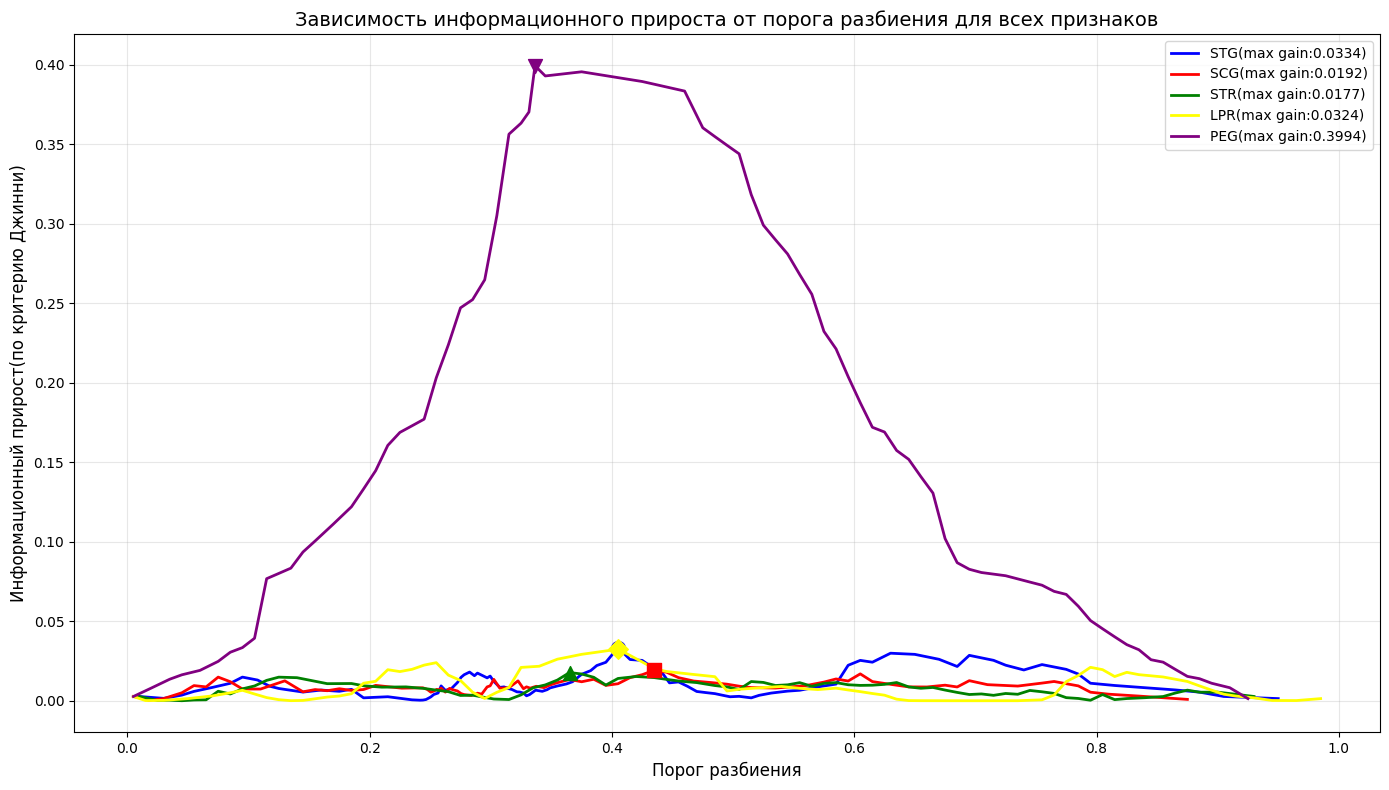

СТАТИСТИКА ПО ПРИЗНАКАМ

STG:
Количество порогов: 103
Диапазон: [0.01,0.95]
Луучший порог: 0.4050
Максимальный информационный прирост: 0.0334

SCG:
Количество порогов: 88
Диапазон: [0.01,0.88]
Луучший порог: 0.4350
Максимальный информационный прирост: 0.0192

STR:
Количество порогов: 82
Диапазон: [0.01,0.93]
Луучший порог: 0.3650
Максимальный информационный прирост: 0.0177

LPR:
Количество порогов: 79
Диапазон: [0.01,0.98]
Луучший порог: 0.4050
Максимальный информационный прирост: 0.0324

PEG:
Количество порогов: 79
Диапазон: [0.01,0.93]
Луучший порог: 0.3365
Максимальный информационный прирост: 0.3994
STG: максимальный прирост - 0.0334 → ОТВРАТИТЕЛЬНО
SCG: максимальный прирост - 0.0192 → ОТВРАТИТЕЛЬНО
STR: максимальный прирост - 0.0177 → ОТВРАТИТЕЛЬНО
LPR: максимальный прирост - 0.0324 → ОТВРАТИТЕЛЬНО
PEG: максимальный прирост - 0.3994 → ОТЛИЧНО


In [36]:
# Делим переменные - последняя целевая, признаки в первых пяти
# Первый оказался Unnamed -
X=students_df.iloc[:,1:6]
y=students_df.iloc[:,-1]
feature_names=X.columns.tolist()

# График с 5 кривыми порог - значения критерия Джини
plt.figure(figsize=(14,8))

colors=["blue","red","green","yellow","purple"]

# Для статистики
features_info=[]


# zip для объединения списка в кортеж, для прохождения по нима
for i, (feature_name,color,distict) in enumerate(zip(feature_names,colors,disticts)):
  feature_vector=X[feature_name].values

  # Классификация, Джинни
  thresholds, gains, best_threshold, best_gain=find_best_split2(feature_vector,y,task="classification",feature_type="real")
  features_info.append({
      "name": feature_name,
      "thresholds": thresholds,
      "gains": gains,
      "best_threshold": best_threshold,
      "best_gain": best_gain
  })

  if len(thresholds)>0:
    # Просортируем, чтобы они красиво подряд разлеглись
    if len(thresholds)>1:
      sort_index=np.argsort(thresholds)
      thresholds_sorted=thresholds[sort_index]
      gains_sorted=gains[sort_index]
    else:
      thresholds_sorted=thresholds
      gains_sorted=gains

    # Строим графики
    plt.plot(thresholds_sorted,gains_sorted,color=color,linewidth=2,label=f"{feature_name}(max gain:{best_gain:.4f})" if best_gain else f"{feature_name}")
    # Лучший порожек
    if best_threshold is not None and best_gain is not None:
      # zorder - чтобы чуть лучше видно было, отоборажение поверх
      plt.scatter(best_threshold,best_gain,color=color,s=100,marker=distict,zorder=5)

plt.xlabel("Порог разбиения",fontsize=12)
plt.ylabel("Информационный прирост(по критерию Джинни)",fontsize=12)
plt.title("Зависимость информационного прироста от порога разбиения для всех признаков",fontsize=14)
plt.legend(loc="best",fontsize=10)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 23)
print("СТАТИСТИКА ПО ПРИЗНАКАМ")
print("=" * 23)
for info in features_info:
  print(f"\n{info["name"]}:")
  if len(info["thresholds"])>0:
    print(f"Количество порогов: {len(info["thresholds"])}")
    print(f"Диапазон: [{info["thresholds"].min():.2f},{info["thresholds"].max():.2f}]")
    if info["best_threshold"] is not None:
      print(f"Луучший порог: {info["best_threshold"]:.4f}")
    if info["best_gain"] is not None:
      print(f"Максимальный информационный прирост: {info["best_gain"]:.4f}")
  else:
    print("Нет порогов для разбиения")


for i, info in enumerate(features_info):
    if info['best_gain'] is not None:
        if info['best_gain'] > 0.15:
            quality="ОТЛИЧНО"
        elif info['best_gain'] > 0.1:
            quality="НУ ПОЛУЧШЕ"
        elif info['best_gain']>0.05:
            quality="МХЕ"
        else:
            quality="ОТВРАТИТЕЛЬНО"

        print(f"{info['name']}: максимальный прирост - {info['best_gain']:.4f} → {quality}")



PEG - лучший прирост, что гораздо выше(в 10-20 раз), чем остальные. PEG отлично сможет разделить классы, а остальные не смогут. Получается при построении дерева используем PEG

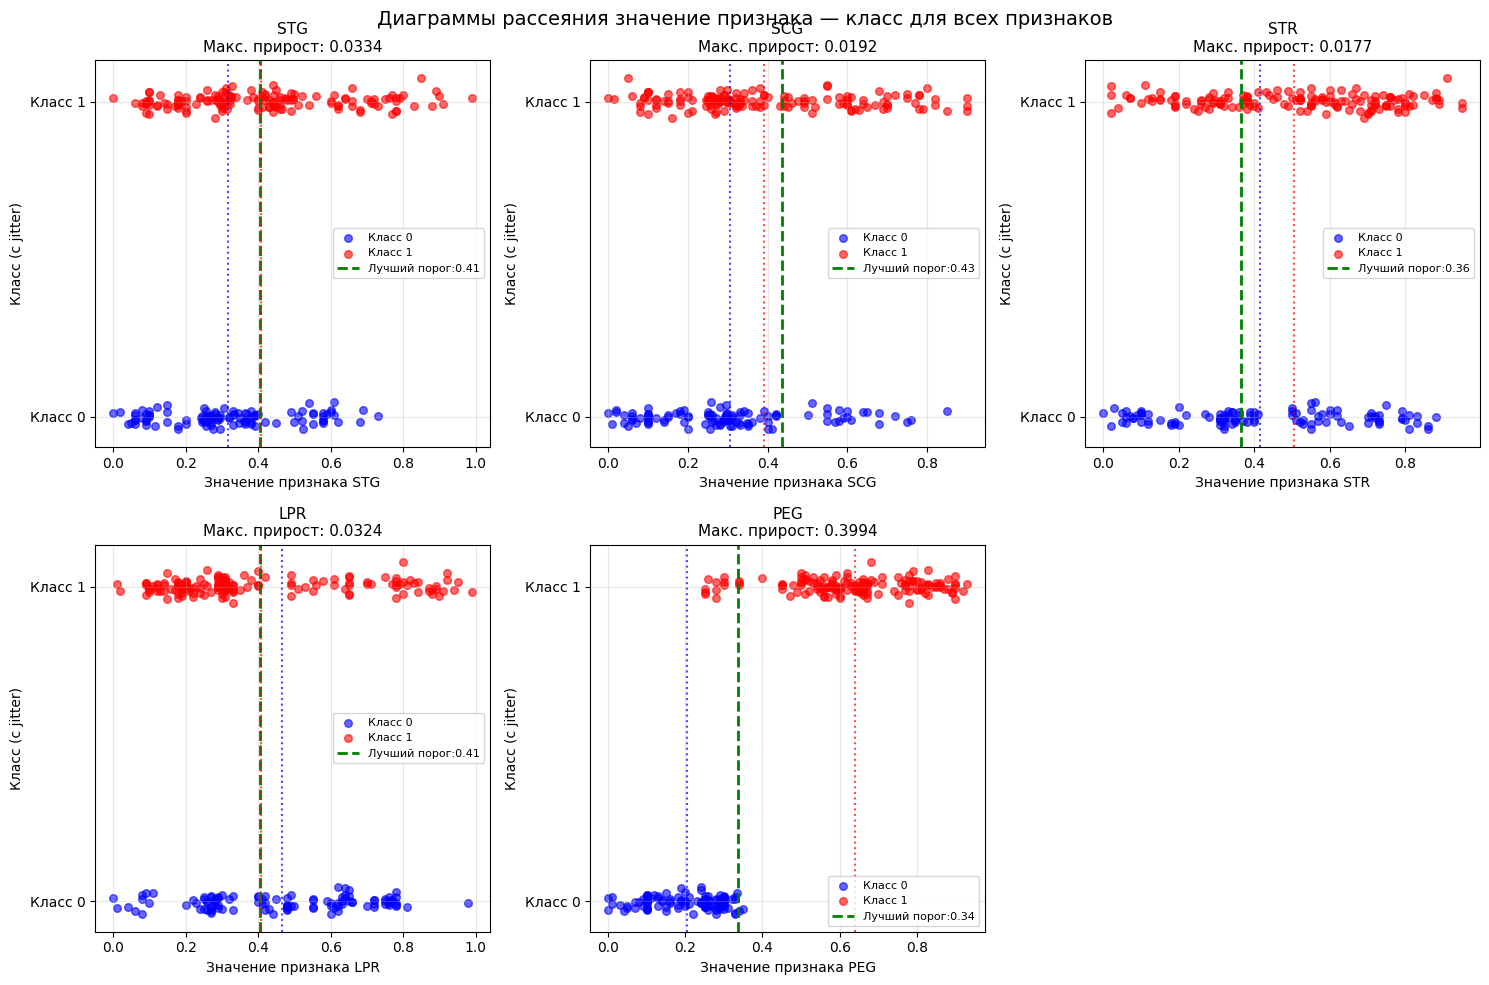

In [37]:
# Диаграммы рассеяния
# Теперь создаем диаграммы рассеяния "значение признака — класс"
fig,axes=plt.subplots(2,3,figsize=(15, 10))
axes=axes.flatten()

# Добавляем небольшой случайный шум к классам для лучшей визуализации
np.random.seed(42)
jitter=np.random.normal(0, 0.02, len(y))
y_jittered=y + jitter

for i,(feature_name,color,info) in enumerate(zip(feature_names,colors,features_info)):
    feature_vector=X[feature_name].values

    # Строим диаграмму рассеяния
    # Класс 0
    mask_0=(y == 0)
    axes[i].scatter(feature_vector[mask_0],y_jittered[mask_0],alpha=0.6,s=30,color="blue",label="Класс 0")

    # Класс 1
    mask_1=(y==1)
    axes[i].scatter(feature_vector[mask_1],y_jittered[mask_1],alpha=0.6,s=30,color="red",label="Класс 1")

    # Если нашли лучший порог, рисуем вертикальную линию
    if info["best_threshold"] is not None:
        axes[i].axvline(x=info["best_threshold"],color="green",linestyle="--",linewidth=2,label=f"Лучший порог:{info["best_threshold"]:.2f}")

    # Вычисляем средние значения для каждого класса
    mean_class_0=np.mean(feature_vector[mask_0]) if np.sum(mask_0)>0 else 0
    mean_class_1=np.mean(feature_vector[mask_1]) if np.sum(mask_1)>0 else 0

    # Рисуем линии средних значений
    axes[i].axvline(x=mean_class_0,color="blue",linestyle=":",alpha=0.7,linewidth=1.5)
    axes[i].axvline(x=mean_class_1,color="red",linestyle=":",alpha=0.7,linewidth=1.5)

    axes[i].set_xlabel(f"Значение признака {feature_name}",fontsize=10)
    axes[i].set_ylabel("Класс (с jitter)",fontsize=10)

    # Добавляем информационный прирост в заголовок
    if info["best_gain"] is not None:
        axes[i].set_title(f"{feature_name}\nМакс. прирост: {info["best_gain"]:.4f}",fontsize=11)
    else:
        axes[i].set_title(feature_name,fontsize=11)

    axes[i].set_yticks([0,1])
    axes[i].set_yticklabels(["Класс 0","Класс 1"])
    axes[i].legend(loc="best",fontsize=8)
    axes[i].grid(True,alpha=0.3)

# Скрываем последний пустой subplot, если признаков меньше 6
if len(feature_names)<6:
    for j in range(len(feature_names),6):
        axes[j].axis("off")

plt.suptitle("Диаграммы рассеяния значение признака — класс для всех признаков",fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

Как и ожидалось, PEG лучше всего вертикально разделяет классы. (PEG - previous exam grade - оценка за предыдущий экзамен лучше определяет знания студента)

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

Лучше в тексте напишу.

Точно делим по PEG с порогом 0.3365.

Да, согласуется, потому что на диаграмме рассеяния чёткое вертикальное деление, хотя чуть-чуть класс 1 зашёл к классу 0, но это не критично. Для других - они там везде разбросаны - плохое деление.

У PEG можно заметить острый высокий пик - получается высокий острый пик - одно значение очень выраженное. Резкий подьём и спуск - в маленьком диапазончике пик, а в других местах сильно спускается.

Они плоские у X - то есть дают примерно одинаковый прирост, очень кривенькие (много пиков, сложно выразить оптимальный).

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [38]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
df = pd.read_csv('agaricus-lepiota.data', header=None)

print(f"Данные загружены. Размер: {df.shape}")
print(df.head())


Данные загружены. Размер: (8124, 23)
  0  1  2  3  4  5  6  7  8  9   ... 13 14 15 16 17 18 19 20 21 22
0  p  x  s  n  t  p  f  c  n  k  ...  s  w  w  p  w  o  p  k  s  u
1  e  x  s  y  t  a  f  c  b  k  ...  s  w  w  p  w  o  p  n  n  g
2  e  b  s  w  t  l  f  c  b  n  ...  s  w  w  p  w  o  p  n  n  m
3  p  x  y  w  t  p  f  c  n  n  ...  s  w  w  p  w  o  p  k  s  u
4  e  x  s  g  f  n  f  w  b  k  ...  s  w  w  p  w  o  e  n  a  g

[5 rows x 23 columns]


In [39]:
# Определяем целевую переменную и признаки
# Первый столбец - edible poisonous
y=df.iloc[:,0]
# Все остальные признаки
X=df.iloc[:,1:]

# Теперь LabelEncoder ко всем столбцам
label_encoders={}
X_encoded=pd.DataFrame()

for c in X.columns:
  le=LabelEncoder()
  # Строки преобразуем
  X_encoded[c]=le.fit_transform(X[c].astype(str))
  label_encoders[c]=le

# Теперь для целевой переменной
le_target=LabelEncoder()
y_encoded=le_target.fit_transform(y.astype(str))

# Проверим попечатаем
print(X_encoded.head())
print(f"Закодированная целевая:{np.unique(y_encoded)}")

   1   2   3   4   5   6   7   8   9   10  ...  13  14  15  16  17  18  19  \
0   5   2   4   1   6   1   0   1   4   0  ...   2   7   7   0   2   1   4   
1   5   2   9   1   0   1   0   0   4   0  ...   2   7   7   0   2   1   4   
2   0   2   8   1   3   1   0   0   5   0  ...   2   7   7   0   2   1   4   
3   5   3   8   1   6   1   0   1   5   0  ...   2   7   7   0   2   1   4   
4   5   2   3   0   5   1   1   0   4   1  ...   2   7   7   0   2   1   0   

   20  21  22  
0   2   3   5  
1   3   2   1  
2   3   2   3  
3   2   3   5  
4   3   0   1  

[5 rows x 22 columns]
Закодированная целевая:[0 1]


In [47]:
# Делим на две части - обучающую и тестовую
# Стратификация для сохранения распределения классов
X_train, X_test, y_train, y_test=train_test_split(
    X_encoded.values,
    y_encoded,
    test_size=0.5,
    random_state=42,
    stratify=y_encoded
)
print(f"Обучающая выборка:{X_train.shape[0]} объектов")
print(f"Тестовая выборка:{X_test.shape[0]} объектов")

Обучающая выборка:4062 объектов
Тестовая выборка:4062 объектов


In [49]:
feature_types=["categorical"]*X_train.shape[1]

# Ограничение по глубине 5 для данных только с категориальными признаками
# Всё остальное было по пробе пера - каждый раз новые min split и min leaf
print("ОБУЧЕНИЕ РЕШАЮЩЕГО ДЕРЕВА!")
tree=DecisionTree(
    feature_types=feature_types,
    task="classification",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)
tree.fit(X_train,y_train)

# Теперь предсказываем
y_pred=tree.predict(X_test)

accuracy=np.mean(y_pred==y_test)
print(f"Точность на половине данных:{accuracy:.4f}")
print(f"Это соответствует {int(accuracy*len(y_test))} правильным предсказаниям из {len(y_test)}")

ОБУЧЕНИЕ РЕШАЮЩЕГО ДЕРЕВА!
Точность на половине данных:0.9988
Это соответствует 4057 правильным предсказаниям из 4062


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score

In [ ]:
data = pd.read_csv("diabetes.csv")
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

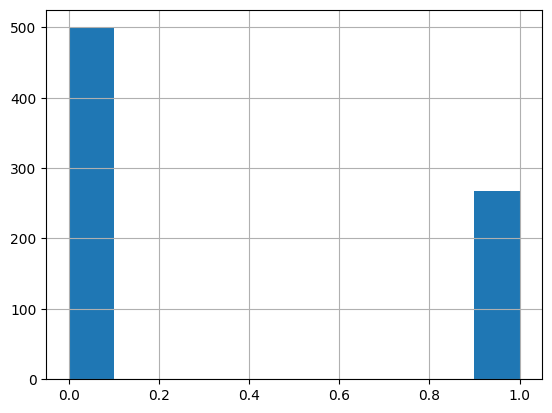

In [ ]:
data["Outcome"].hist()
plt.show()

**Задание 3.1 (1 балл)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [ ]:
#признаки и целевая переменная
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

#70% - обучение, 30% - тест
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)
#обучающая и валидационная
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42
)

print(f"обучающая: {X_train.shape[0]} объектов")
print(f"валидационная: {X_val.shape[0]} объектов")
print(f"тестовая: {X_test.shape[0]} объектов")

best_f1 = 0
best_params = {}
max_depth_values = [3, 5, 7, 10, 15, 20, None]
min_samples_leaf_values = [1, 2, 5, 10, 20]

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_val)
        f1 = f1_score(y_val, y_pred)

        #лучшие параметры
        if f1 > best_f1:
            best_f1 = f1
            best_params = {"max_depth": max_depth, "min_samples_leaf": min_samples_leaf}

print(f"Лучшие параметры: {best_params}")
print(f"Лучшая F1-мера на валидационной выборке: {best_f1:.4f}")
best_tree = DecisionTreeClassifier(
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42
)
best_tree.fit(X_train_full, y_train_full)

#предикт на тествыборке
y_pred_test = best_tree.predict(X_test)
y_pred_proba_test = best_tree.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
auc_roc = roc_auc_score(y_test, y_pred_proba_test)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

обучающая: 375 объектов
валидационная: 162 объектов
тестовая: 231 объектов
Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 5}
Лучшая F1-мера на валидационной выборке: 0.6667
Accuracy: 0.7706
Precision: 0.7143
Recall: 0.5625
AUC-ROC: 0.7937


Одиночное дерево показало наивысшую точность accuracy среди всех трех моделей.

Однако имеет низкий recall 0.5625, что означает, что модель пропускает почти 44% случаев диабета.

Высокий precision 0.7143 говорит о том, что когда модель предсказывает диабет, она часто права.

**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [ ]:
from sklearn.ensemble import BaggingClassifier

#50 деревьев
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train_full, y_train_full)

y_pred_bagging = bagging.predict(X_test)
y_pred_proba_bagging = bagging.predict_proba(X_test)[:, 1]

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
auc_roc_bagging = roc_auc_score(y_test, y_pred_proba_bagging)

print(f"Accuracy: {accuracy_bagging:.4f}")
print(f"Precision: {precision_bagging:.4f}")
print(f"Recall: {recall_bagging:.4f}")
print(f"AUC-ROC: {auc_roc_bagging:.4f}")

Accuracy: 0.7489
Precision: 0.6310
Recall: 0.6625
AUC-ROC: 0.8083


Бэггинг снизил точность, но улучшил AUC-ROC до 0.8083.

Recall значительно улучшился с 0.5625 до 0.6625, что означает лучшую способность обнаруживать случаи диабета.
Ухудшение precision с 0.7143 до 0.6310 указывает на увеличение ложноположительных предсказаний.
Бэггинг показал наилучший баланс между обнаружением диабета и общей производительностью

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше? Сделайте выводы

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "n_estimators": [50]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train_full, y_train_full)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая F1-мера: {grid_search.best_score_:.4f}")

#лучшие параметры
best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=grid_search.best_params_["max_depth"],
    min_samples_split=grid_search.best_params_["min_samples_split"],
    random_state=42
)
best_rf.fit(X_train_full, y_train_full)
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"AUC-ROC: {auc_roc_rf:.4f}")

print("\n")
print(f"Decision Tree - Accuracy: {accuracy:.4f}, AUC-ROC: {auc_roc:.4f}")
print(f"Bagging - Accuracy: {accuracy_bagging:.4f}, AUC-ROC: {auc_roc_bagging:.4f}")
print(f"Random Forest - Accuracy: {accuracy_rf:.4f}, AUC-ROC: {auc_roc_rf:.4f}")

Лучшие параметры: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 50}
Лучшая F1-мера: 0.6377
Accuracy: 0.7143
Precision: 0.5875
Recall: 0.5875
AUC-ROC: 0.7974


Decision Tree - Accuracy: 0.7706, AUC-ROC: 0.7937
Bagging - Accuracy: 0.7489, AUC-ROC: 0.8083
Random Forest - Accuracy: 0.7143, AUC-ROC: 0.7974


Случайный лес показал наихудшие результаты по точности и precision.
Однако имеет хороший AUC-ROC 0.7974, лишь немного уступая бэггингу.
Более глубокая оптимальная глубина 15 против 5 у одиночного деревауказывает на то, что ансамбль методов лучше справляется с переобучением.

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

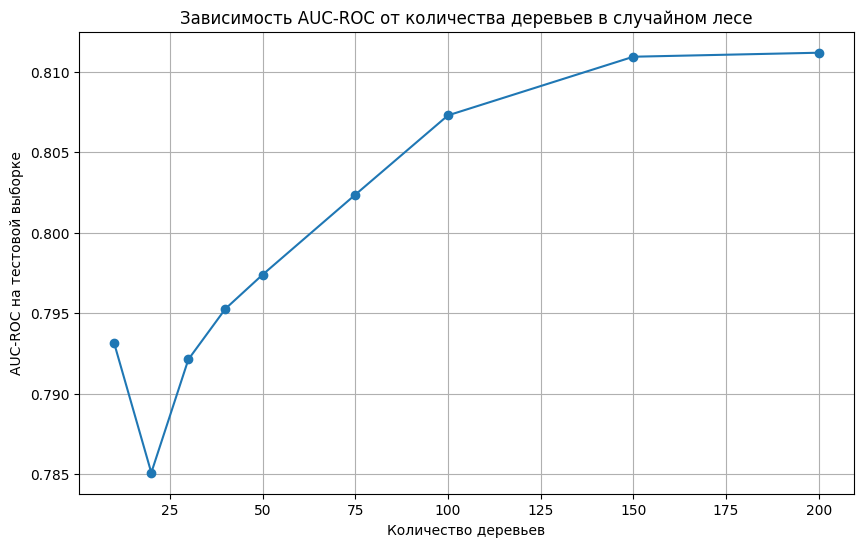

Анализ зависимости AUC-ROC от количества деревьев:
n_estimators=10: AUC-ROC=0.7931
n_estimators=20: AUC-ROC=0.7851
n_estimators=30: AUC-ROC=0.7921
n_estimators=40: AUC-ROC=0.7953
n_estimators=50: AUC-ROC=0.7974
n_estimators=75: AUC-ROC=0.8024
n_estimators=100: AUC-ROC=0.8073
n_estimators=150: AUC-ROC=0.8109
n_estimators=200: AUC-ROC=0.8112


In [ ]:
import matplotlib.pyplot as plt

#n_estimators
n_estimators_list = [10, 20, 30, 40, 50, 75, 100, 150, 200]
auc_scores = []

for n in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        max_depth=grid_search.best_params_["max_depth"],
        min_samples_split=grid_search.best_params_["min_samples_split"],
        random_state=42
    )
    rf_temp.fit(X_train_full, y_train_full)

    y_pred_proba_temp = rf_temp.predict_proba(X_test)[:, 1]
    auc_temp = roc_auc_score(y_test, y_pred_proba_temp)
    auc_scores.append(auc_temp)

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, auc_scores, marker="o")
plt.xlabel("Количество деревьев")
plt.ylabel("AUC-ROC на тестовой выборке")
plt.title("Зависимость AUC-ROC от количества деревьев в случайном лесе")
plt.grid(True)
plt.show()


print("Анализ зависимости AUC-ROC от количества деревьев:")
for n, auc in zip(n_estimators_list, auc_scores):
    print(f"n_estimators={n}: AUC-ROC={auc:.4f}")

При малом количестве деревьев 10-20 ансамбль еще недостаточно стабилен
Результаты сильно зависят от конкретной случайной инициализации каждого дерева
При 10 деревьях могла случайно сложиться более удачная комбинация
При 20 деревьях добавились "неудачные" деревья, которые ухудшили общий результат

50-100 деревьев представляют хороший баланс между производительностью и вычислительными затратами.

Увеличение количества деревьев свыше 100 дает минимальное улучшение качества.

Закон убывающей отдачи явно проявляется после 50 деревьев.

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

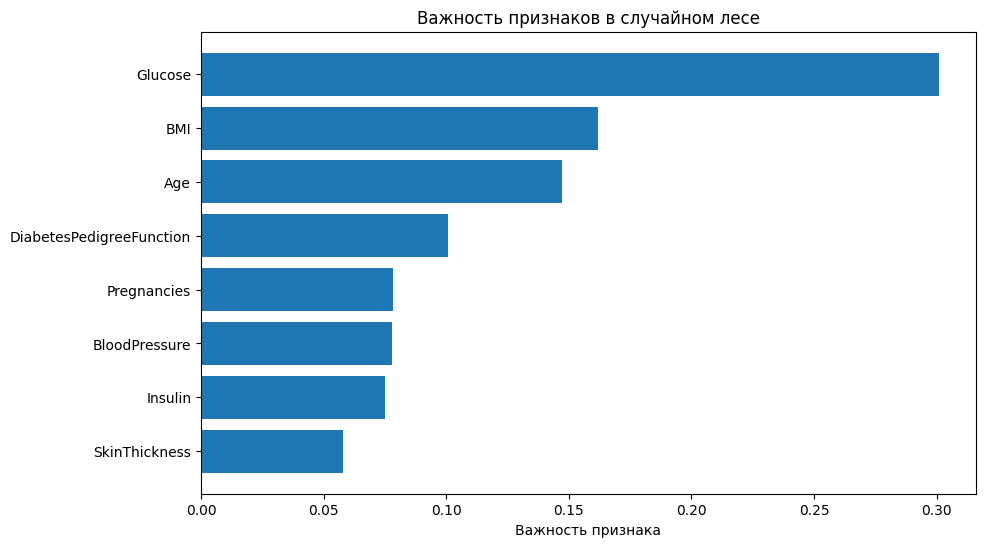

Наиболее важные признаки:
                    Feature  Importance
1                   Glucose    0.300994
5                       BMI    0.161782
7                       Age    0.147366
6  DiabetesPedigreeFunction    0.100888
0               Pregnancies    0.078135

Самый важный признак: Glucose (важность: 0.3010)


In [ ]:
feature_importances = best_rf.feature_importances_
feature_names = X.columns

#DataFrame с важностью признаков
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Важность признака")
plt.title("Важность признаков в случайном лесе")
plt.gca().invert_yaxis()
plt.show()

print("Наиболее важные признаки:")
print(importance_df.head())

print(f"\nСамый важный признак: {importance_df.iloc[0]["Feature"]} "
      f"(важность: {importance_df.iloc[0]["Importance"]:.4f})")

Уровень глюкозы - наиболее значимый предиктор диабета 30% важности, что соответствует медицинским знаниям.
BMI и возраст также играют важную роль в предсказании диабета.